In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Read the data

In [2]:
corolla_data = pd.read_csv('/DataScinceExlr/Assignments/7. MLR/ToyotaCorolla - MLR.csv')

### Step 2: Examine the data

In [3]:
corolla_data.shape

(1436, 11)

In [4]:
corolla_data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
corolla_data.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [6]:
corolla_data.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [7]:
corolla_data.index

RangeIndex(start=0, stop=1436, step=1)

In [8]:
# Display dataset structure, data types, and non-null counts
corolla_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [9]:
# Examine for missing values
corolla_data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [41]:
corolla_data.shape

(1436, 11)

In [42]:
# Calculate key statistics
corolla_data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


#### Step 3: Clean the data

In [43]:
data1 = corolla_data.copy()

In [44]:
data1.shape

(1436, 11)

In [45]:
#data1['Fuel_Type']= data1['Fuel_Type'].astype('category')
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [46]:
data1.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1431    False
1432    False
1433    False
1434    False
1435    False
Length: 1436, dtype: bool

In [47]:
data1[data1.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [48]:
# remove the duplicates 
data1.drop_duplicates(inplace=True)

In [49]:
# Verify unique values in the column 
data1['Cylinders'].unique()

array([4], dtype=int64)

#### By reffering the describe data of the data set - Cylinders: has mean = 4.0, std = 0 , constant column, no predictive power so will drop the column.

In [50]:
data1.drop('Cylinders', axis=1, inplace=True)

In [51]:
# correct the column name
data1.rename(columns={'Age_08_04':'Age'}, inplace=True)
data1.columns

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors',
       'Gears', 'Weight'],
      dtype='object')

<Figure size 400x300 with 0 Axes>

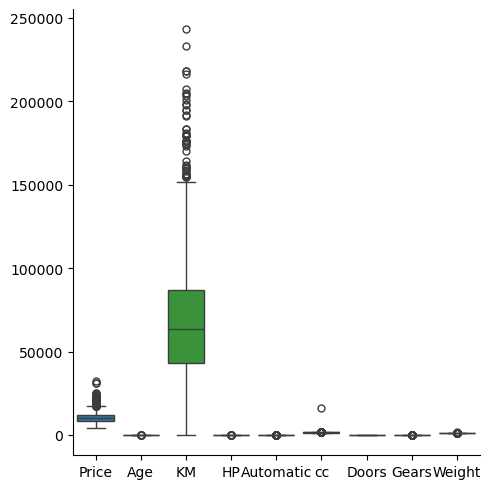

In [52]:
# finding outliers
plt.figure(figsize=(4,3))
sns.catplot(data1, kind='box')
plt.show()

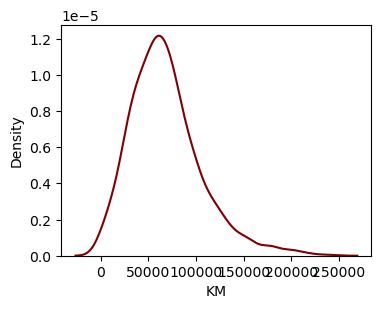

In [53]:
# check the skewness 
plt.figure(figsize=(4,3))
sns.kdeplot(data1['KM'], color='maroon')
plt.show()

In [54]:
# get the KM min, max, std and mean
data1['KM'].describe()

count      1435.000000
mean      68571.782578
std       37491.094553
min           1.000000
25%       43000.000000
50%       63451.000000
75%       87041.500000
max      243000.000000
Name: KM, dtype: float64

In [55]:
# calculate the Q1, Q3 and IQR for setting the upper limit and lower limit
Q1 = data1['KM'].quantile(0.25)
Q3 = data1['KM'].quantile(0.75)
IQR = Q3 - Q1
Q1, Q3, IQR

(43000.0, 87041.5, 44041.5)

In [56]:
# get the upper limit
upper_limit = Q3 + 1.5 * IQR
upper_limit

153103.75

In [57]:
# checking the values above the uppper limit
data1[data1['KM']>upper_limit]

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
186,6950,43,243000,Diesel,69,0,1900,3,5,1110
187,9500,38,180638,Diesel,90,0,2000,4,5,1160
188,11950,40,179860,Diesel,90,0,2000,5,5,1205
189,7750,43,178858,CNG,110,0,1600,3,5,1084
190,11950,40,161000,Diesel,69,0,1900,3,5,1105
191,4350,44,158320,Diesel,69,0,1800,5,5,1110
378,6500,53,216000,Diesel,69,0,1900,3,5,1110
379,6400,51,198167,Diesel,69,0,1900,4,5,1095
380,7000,53,176000,Diesel,69,0,1900,3,5,1105
381,7750,54,174139,Diesel,72,0,2000,4,5,1100


In [58]:
# set the values to the upper limit
data1['KM']= np.where(data1['KM']> upper_limit, upper_limit, data1['KM'])

In [59]:
data1[data1['KM']>upper_limit]

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight


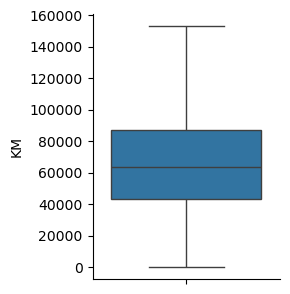

In [60]:
# cheking the outliers
sns.catplot(data1['KM'], kind='box', height=3)
plt.show()

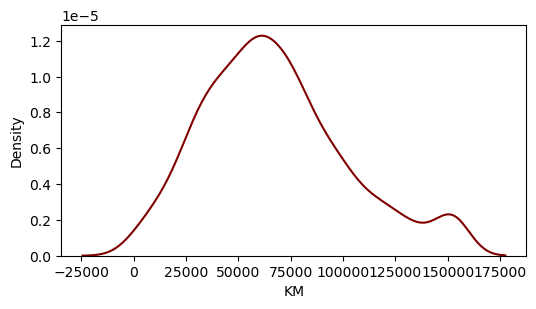

In [61]:
plt.figure(figsize=(6,3))
sns.kdeplot(data1['KM'], color='maroon')
plt.show()

In [62]:
# making the fuletype column to bainary values 
data2 = pd.get_dummies(data1, columns=['Fuel_Type'], drop_first=True)

In [63]:
# Compute the correlation matrix to examine relationships among all features
corr_matrix = data2.corr()

# Display the correlation matrix
corr_matrix

,Price,Age,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
Price,1.000000,-0.876273,-0.586871,0.314134,0.033928,0.124375,0.183604,0.063831,0.575869,0.046612,-0.031356
Age,-0.876273,1.000000,0.530947,-0.155293,0.031354,-0.096549,-0.146929,-0.005629,-0.466484,-0.093058,0.088169
KM,-0.586871,0.530947,1.000000,-0.315177,-0.082221,0.092040,-0.036618,0.019829,-0.047267,0.376921,-0.408052
HP,0.314134,-0.155293,-0.315177,1.000000,0.013313,0.035207,0.091803,0.209642,0.087143,-0.537116,0.492362
Automatic,0.033928,0.031354,-0.082221,0.013313,1.000000,0.066934,-0.027492,-0.098582,0.058499,-0.084248,0.079997
cc,0.124375,-0.096549,0.092040,0.035207,0.066934,1.000000,0.079254,0.014732,0.335077,0.326780,-0.314200
Doors,0.183604,-0.146929,-0.036618,0.091803,-0.027492,0.079254,1.000000,-0.160101,0.301734,0.023538,-0.025746
Gears,0.063831,-0.005629,0.019829,0.209642,-0.098582,0.014732,-0.160101,1.000000,0.021238,-0.048706,0.063079
Weight,0.575869,-0.466484,-0.047267,0.087143,0.058499,0.335077,0.301734,0.021238,1.000000,0.564649,-0.557315
Fuel_Type_Diesel,0.046612,-0.093058,0.376921,-0.537116,-0.084248,0.326780,0.023538,-0.048706,0.564649,1.000000,-0.942673


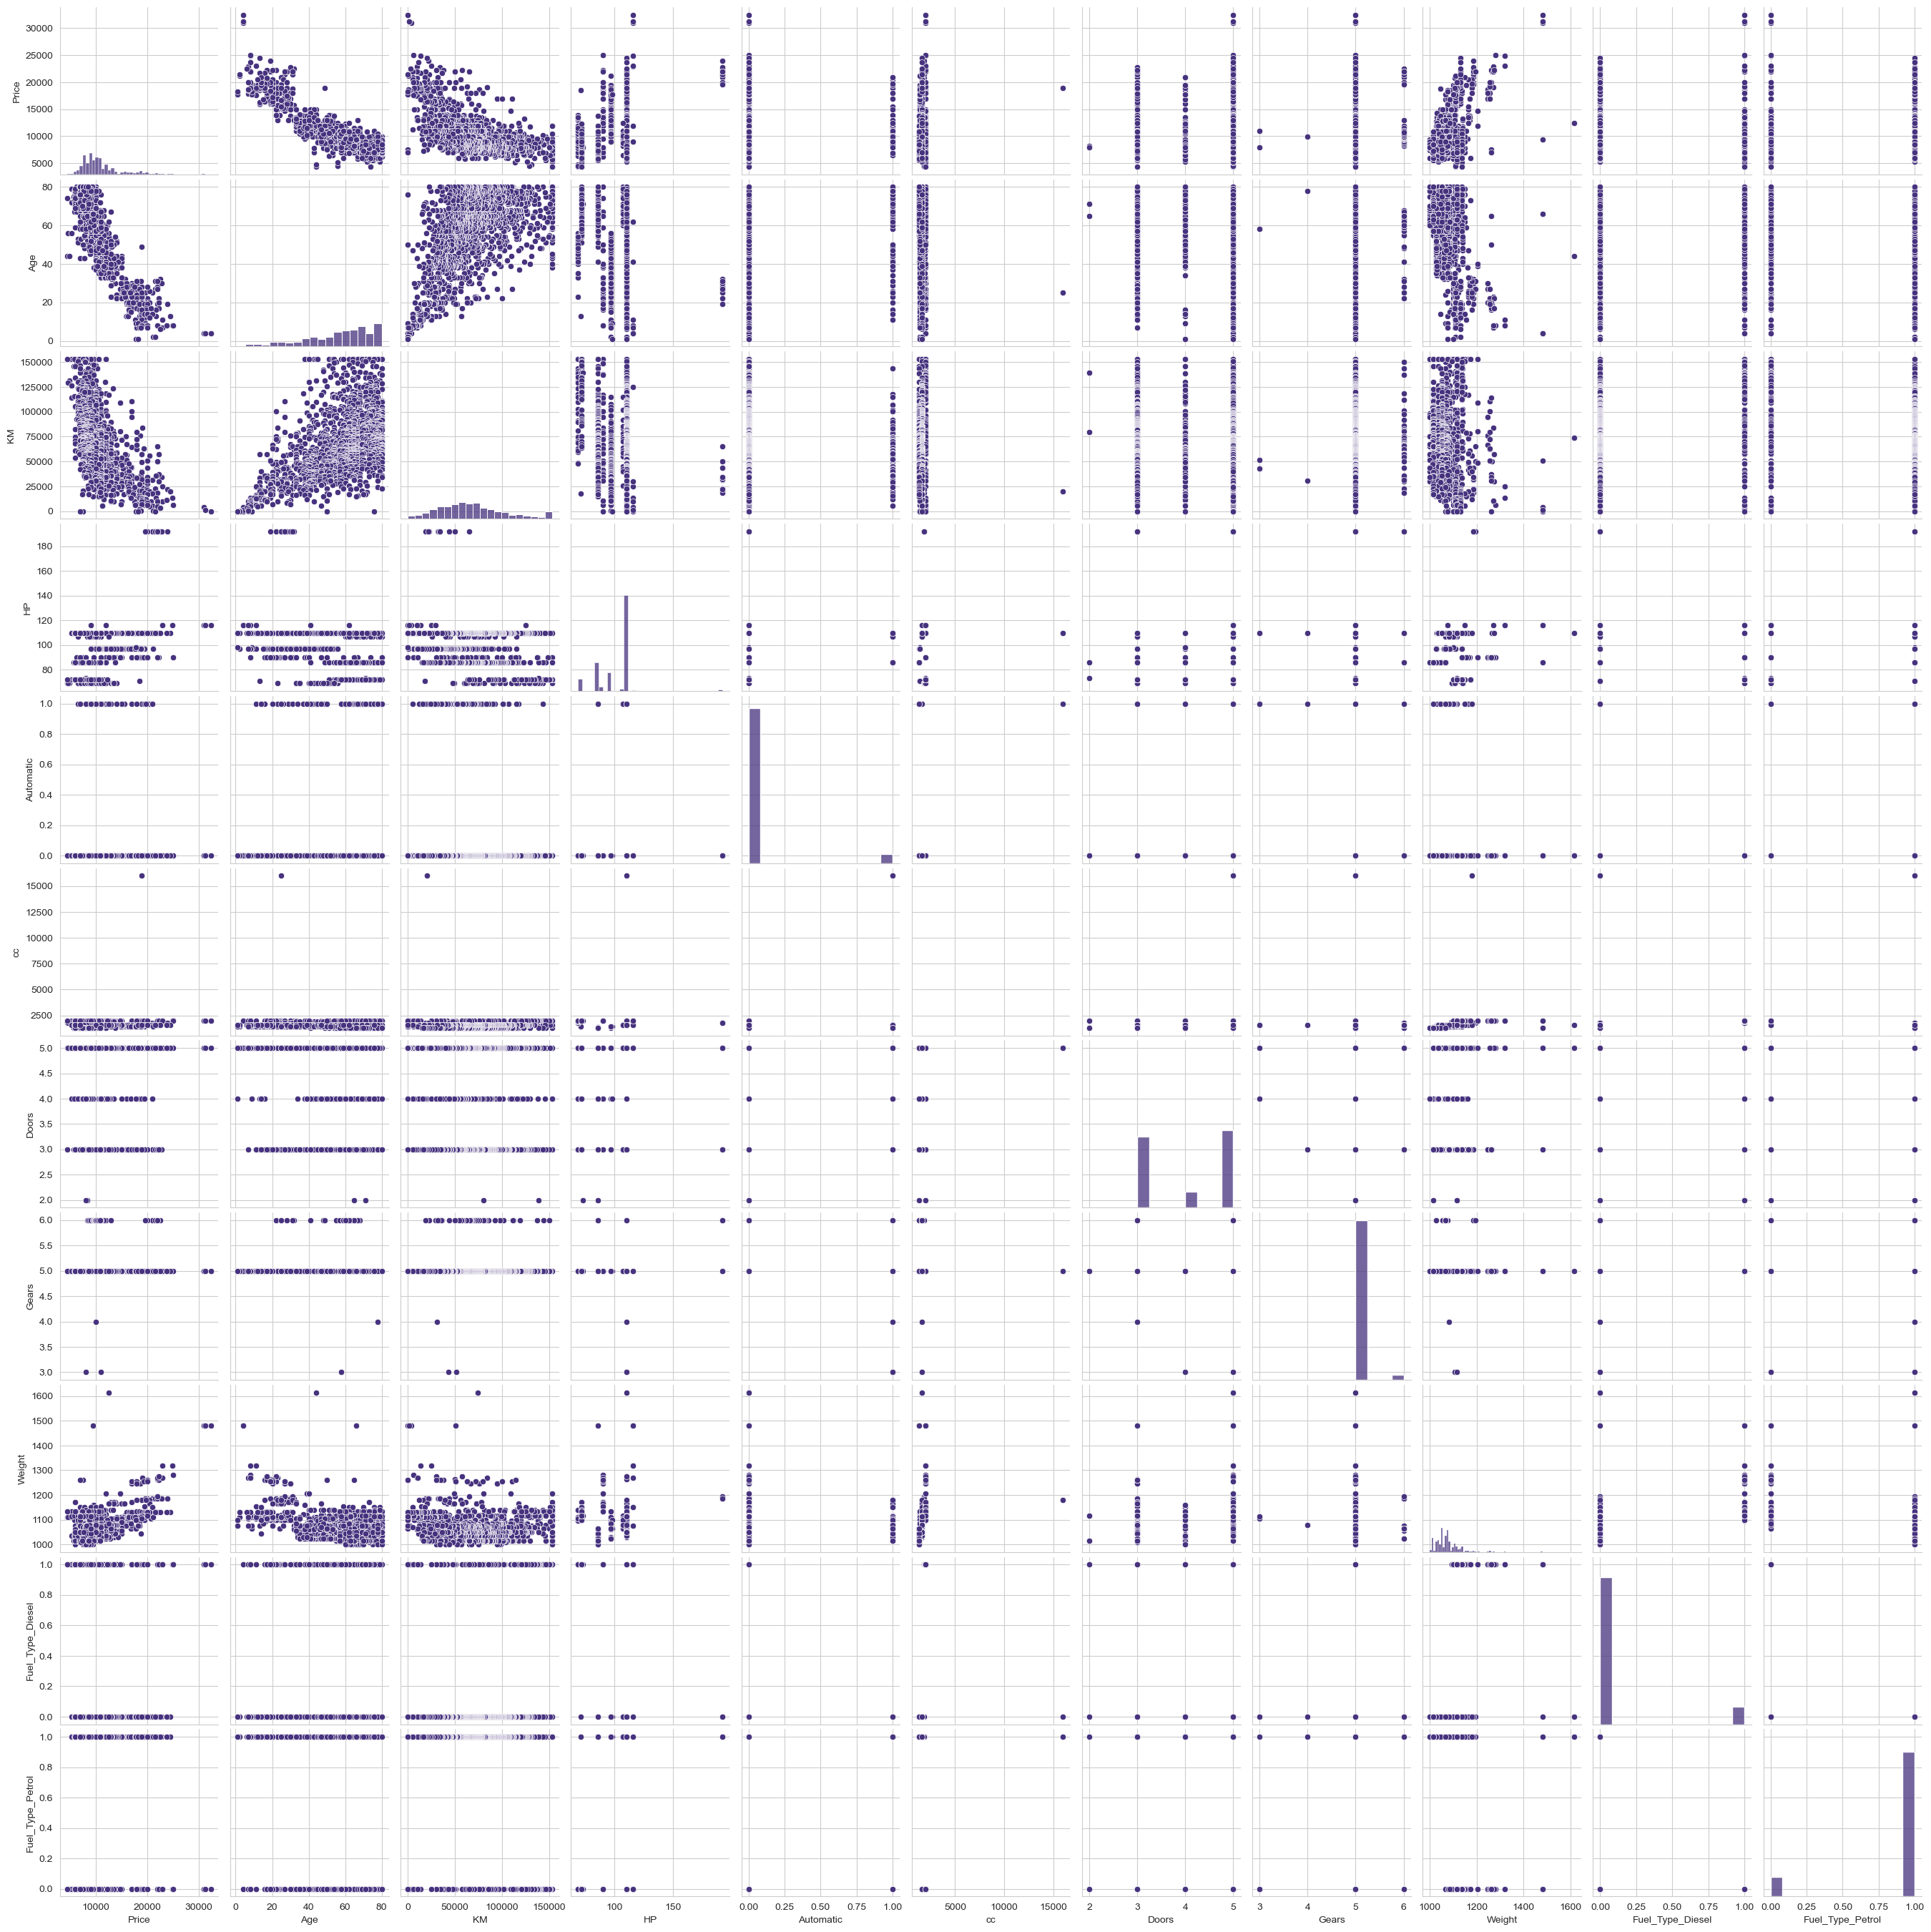

In [64]:
# checking the relations using the scatter plot
sns.set_palette('viridis')
sns.set_style(style='whitegrid')
sns.pairplot(data2)

In [65]:
# Compute correlation matrix for all numerical features
corr_matrix = data2.corr()

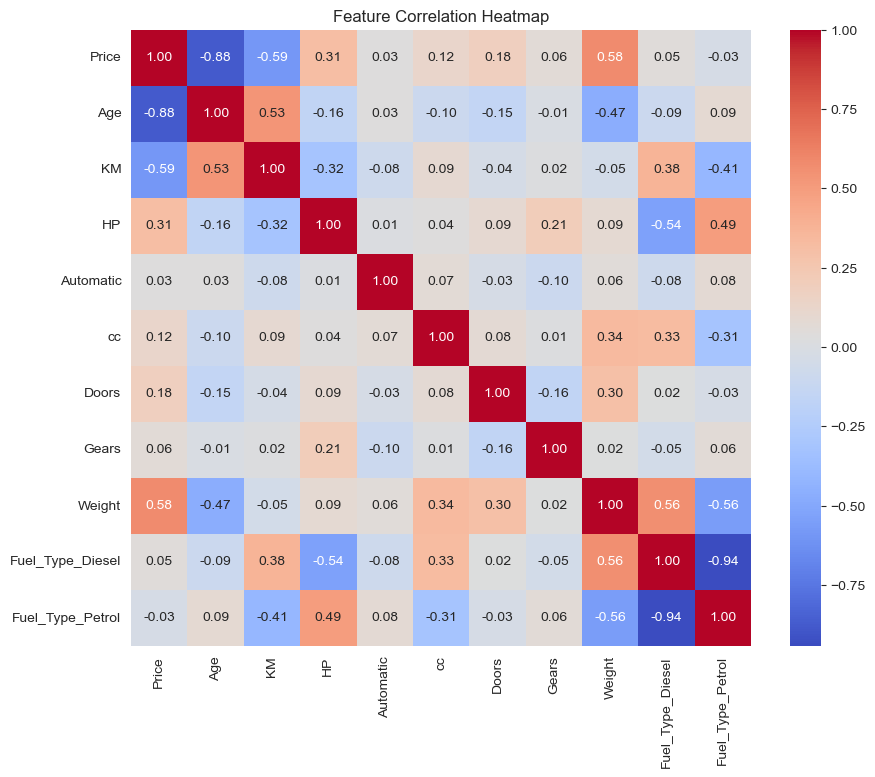

In [66]:
# Visualize feature correlations using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

#### Preparing Models

In [67]:
# using OLS
import statsmodels.formula.api as smf
model = smf.ols('Price~Age+KM+HP+Automatic+cc+Doors+Gears+Weight+Fuel_Type_Diesel+Fuel_Type_Petrol', data=data2).fit()

In [68]:
# using OLS
import statsmodels.formula.api as smf
formula = "Price ~ Age * KM + HP + Automatic + cc + Doors + Gears + Weight + Fuel_Type_Diesel + Fuel_Type_Petrol"
model = smf.ols(formula=formula, data=data2).fit()

In [69]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     910.2
Date:                Mon, 26 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:29:26   Log-Likelihood:                -12295.
No. Observations:                1435   AIC:                         2.461e+04
Df Residuals:                    1423   BIC:                         2.468e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                -5319.4806   1509.896     -3.523      0.000   -8281.342   -2357.619
Fuel_Type_Diesel[T.True]   678.1072    366.007      1.853      0.064     -39.865    1396.079
Fuel_Type_Petrol[T.True]   864.6131    324.431      2.665      0.008     228.198    1501.028
Age                       -157.4403      3.805    -41.382      0.000    -164.904    -149.977
KM                          -0.0598      0.004    -16.136      0.000      -0.067      -0.053
Age:KM                       0.0007   5.71e-05     12.063      0.000       0.001       0.001
HP                          27.3180      3.431      7.963      0.000      20.588      34.048
Automatic                  413.5179    154.169      2.682      0.007     111.095     715.941
cc                          -0.0812      0.088     -0.923      0.356      -0.254       0.091
Doors                      -10.0344     39.124     -0.256      0.798     -86.781      66.712
Gears                      719.0926    189.382      3.797      0.000     347.595    1090.590
Weight                      17.7000      1.193     14.841      0.000      15.361      20.040
==============================================================================
Omnibus:                      173.485   Durbin-Watson:                   1.717
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1173.857
Skew:                          -0.329   Prob(JB):                    1.26e-255
Kurtosis:                       7.382   Cond. No.                     2.21e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.21e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#####  We selected the Ridge regression model because Multiple Linear Regression (MLR) produces results very similar to OLS, and the Lasso model tends to drop some features that are still important for our analysis. Since feature elimination was not desired in this case, we excluded Lasso and proceeded with the Ridge model

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [72]:
# Separate target variable and feature set
X = data2.iloc[:, 1:]
y = data2.iloc[:, 0]

In [73]:
# Scale features to range [0, 1]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
# Expecting performance similar to full MLR, so using Ridge Regression
# Split the standardized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Check dataset shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 10), (287, 10), (1148,), (287,))

In [75]:
# Initialize the Ridge Regression model with regularization strength alpha = 1.0
rdg_model = Ridge(alpha=1.0)

# Fit the model on the training data
rdg_model.fit(X_train, y_train)

Ridge()

#### Model evaluation

In [76]:
from sklearn.metrics import mean_squared_error, r2_score

In [77]:
# train the model
yhat_train = rdg_model.predict(X_train)

In [78]:
# Evaluate model performance on training data
train_mse = mean_squared_error(y_train, yhat_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, yhat_train)

train_mse, train_rmse, train_r2

(1727416.243434705, 1314.3120799242108, 0.8698046208019312)

In [79]:
# Generate predictions on test data
yhat_test = rdg_model.predict(X_test)

# Evaluate model performance on test data
test_mse = mean_squared_error(y_test, yhat_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, yhat_test)

test_mse, test_rmse, test_r2

(2169160.18366341, 1472.8069064420529, 0.8191934652957839)

#### The model shows strong performance on both training and test data, suggesting that it is well-fitted.

### Normalization and Standardization

##### Normalization and standardization enhance model performance by scaling features to a common range. This ensures numerical stability and allows for fair contribution from all features.

### Multicollinearity in Multiple Linear Regression

##### Multicollinearity can be addressed through variable elimination, VIF analysis, Ridge or Lasso regularization, and dimensionality reduction techniques such as PCA.

### Lasso Regression

In [80]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Lasso model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

# ---- Training performance ----
yhat_train = lasso_model.predict(X_train)

train_mse = mean_squared_error(y_train, yhat_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, yhat_train)

print("Training Metrics:", train_mse, train_rmse, train_r2)

# ---- Testing performance ----
yhat_test = lasso_model.predict(X_test)

test_mse = mean_squared_error(y_test, yhat_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, yhat_test)

print("Testing Metrics:", test_mse, test_rmse, test_r2)


Training Metrics: 1727408.6329859768 1314.309184699695 0.8698051944015265
Testing Metrics: 2171675.775160818 1473.6606716475872 0.8189837825877925


In [81]:
# Extract Lasso model coefficients
lasso_coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

lasso_coeff

,Feature,Coefficient
0,Age,-2241.601093
1,KM,-588.059326
2,HP,246.360315
3,Automatic,60.807608
4,cc,-21.521615
5,Doors,-84.214969
6,Gears,85.889500
7,Weight,1378.222070
8,Fuel_Type_Diesel,-128.061783
9,Fuel_Type_Petrol,380.896765


- Age and KM have strong negative effects on price, meaning older cars and higher mileage reduce value significantly.

Weight and HP have strong positive effects, indicating heavier and more powerful cars tend to be priced higher.

Fuel_Type_Petrol increases price relative to the baseline fuel type, while Fuel_Type_Diesel slightly decreases it.

No coefficients were shrunk exactly to zero, indicating that all features were retained at α = 0.1.